In [1]:
1+2

3

In [3]:
import pandas as pd

# 1. 파일 불러오기 (현재 파일은 utf-8로 읽어야 함)
df = pd.read_csv('final_cime (3).csv', encoding='utf-8')

# 2. 엑셀에서 깨지지 않도록 utf-8-sig 형식으로 저장하기
df.to_csv('final_cime_clean.csv', encoding='utf-8-sig', index=False)

In [5]:
df.shape

(219, 17)

In [6]:
df.columns

Index(['스트리머명', '플랫폼', '채널ID', '집계기간_내_최초_방송일', '최고_팔로워', '총_방송시간', '6분_최고채팅',
       '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', '유튜브_유입지수',
       '팬덤지수', 'X_팔로워', '유튜브_구독자', '팬카페_가입자'],
      dtype='str')

In [9]:
df.describe()

,채널ID,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자
count,2.190000e+02,219.000000,219.000000,219.0,219.0,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,9.577135e+05,124.753425,16.456621,0.0,0.0,61.634703,42.337900,751.273973,517.470320,30.200913,26.032877,653.068493,4113.547945,222.995434
std,2.310489e+05,771.490249,28.112188,0.0,0.0,219.893706,179.592135,3921.172161,2525.578009,138.556516,121.609461,3176.824589,21972.823841,1503.123615
min,1.031000e+03,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-100.000000,-100.000000,0.000000,0.000000,0.000000
25%,1.003694e+06,6.000000,2.000000,0.0,0.0,10.000000,6.000000,12.000000,0.000000,-100.000000,-100.000000,0.000000,0.000000,0.000000
50%,1.008816e+06,12.000000,5.000000,0.0,0.0,15.000000,9.000000,45.000000,229.000000,9.500000,24.800000,36.000000,38.000000,0.000000
75%,1.019564e+06,39.000000,18.000000,0.0,0.0,33.000000,20.000000,159.500000,324.500000,83.150000,88.600000,362.500000,407.000000,16.500000
max,1.040332e+06,7976.000000,175.000000,0.0,0.0,2432.000000,2027.000000,38163.000000,33971.000000,772.800000,761.500000,29000.000000,211000.000000,18064.000000


### 첫번째

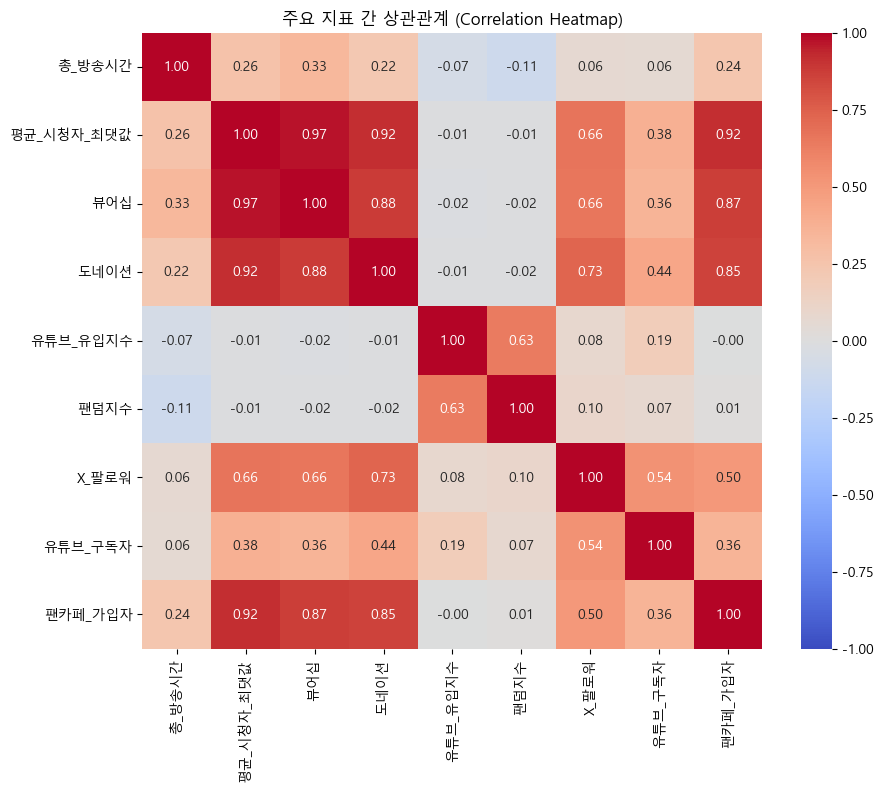

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 환경 설정 (한글 및 마이너스 기호 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic' # 맥(Mac) 유저라면 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False    

# 2. 데이터 불러오기 (앞서 만든 깨지지 않는 파일 사용)
df = pd.read_csv('final_cime_clean.csv', encoding='utf-8-sig')

# 3. 상관관계 분석 (Correlation Heatmap)
# 분석할 수치형 컬럼들만 따로 리스트로 묶어줍니다.
cols_for_corr = ['총_방송시간', '평균_시청자_최댓값', '뷰어십', '도네이션', 
                 '유튜브_유입지수', '팬덤지수', 'X_팔로워', '유튜브_구독자', '팬카페_가입자']

# .corr() 함수로 피어슨 상관계수 행렬을 계산합니다.
corr_matrix = df[cols_for_corr].corr()

# 그래프 그리기
plt.figure(figsize=(10, 8)) # 도화지 크기 설정 (가로 10, 세로 8)
sns.heatmap(corr_matrix, 
            annot=True,       # 각 칸에 실제 상관계수 숫자 표시
            cmap='coolwarm',  # 색상 테마 (파랑-빨강)
            fmt=".2f",        # 소수점 둘째 자리까지 표시
            vmin=-1, vmax=1)  # 상관계수의 최소/최대 범위 설정
            
plt.title('주요 지표 간 상관관계 (Correlation Heatmap)')
plt.show() # VS Code에서 그래프 창을 띄우는 명령어

### 두번째

C:\Users\anna3\AppData\Local\Temp\ipykernel_26340\1701197286.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


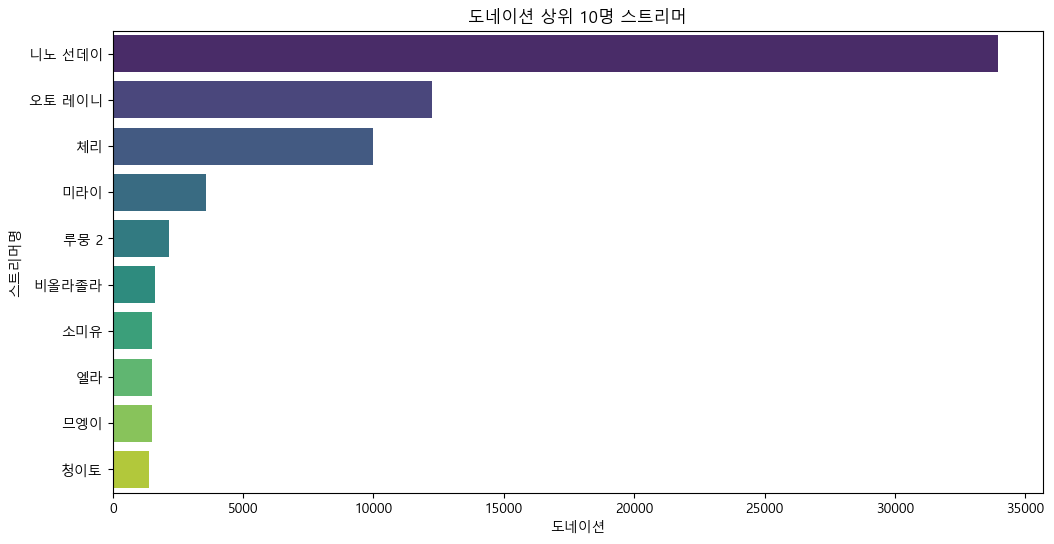

In [16]:
# 4. 랭킹 시각화 (Top 10 by Donation Bar Chart)

# '도네이션' 수치가 가장 높은 상위 10명의 데이터를 추출합니다.
top_donation = df.nlargest(10, '도네이션')

# 그래프 도화지 준비 (가로 12, 세로 6)
plt.figure(figsize=(12, 6)) 

# Seaborn을 활용해 막대그래프 그리기
sns.barplot(
    x='도네이션', 
    y='스트리머명', 
    data=top_donation, 
    palette='viridis'  # 그래프 색상 테마
)

# 그래프 제목과 축 이름 설정
plt.title('도네이션 상위 10명 스트리머')
plt.xlabel('도네이션')
plt.ylabel('스트리머명')

# 그래프 출력
plt.show()

### 세번째

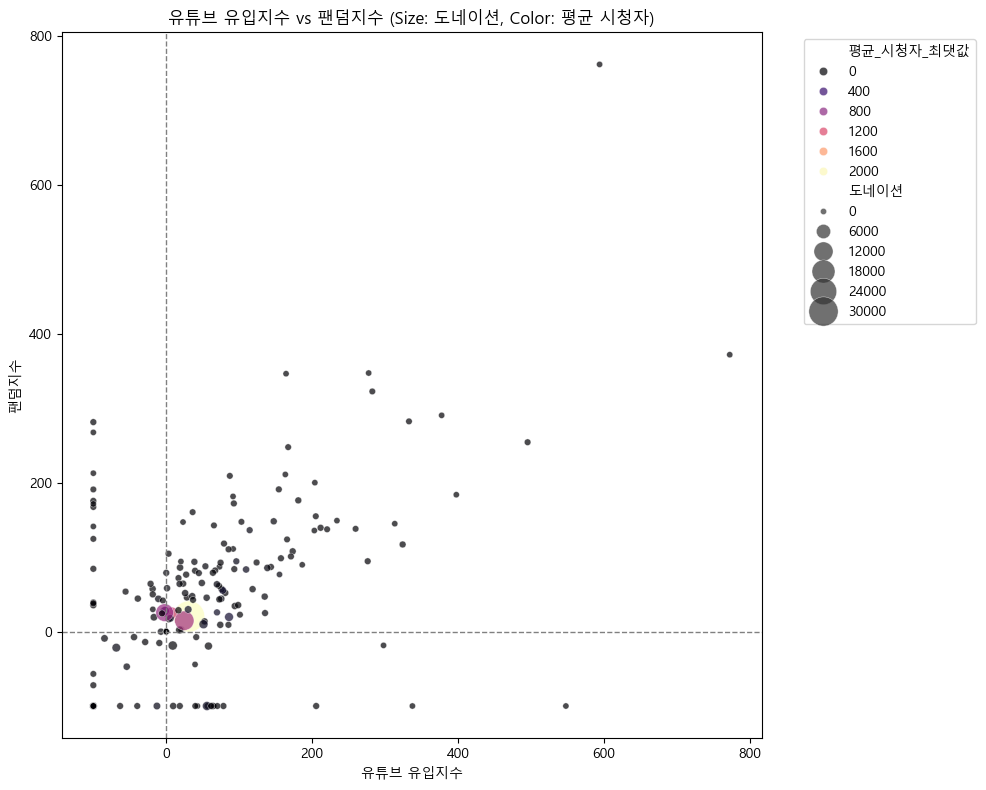

In [17]:
# 5. 다차원 패턴 찾기 (Scatter Plot)

# 도화지 크기 설정
plt.figure(figsize=(10, 8))

# Seaborn 산점도 그리기
sns.scatterplot(
    x='유튜브_유입지수', 
    y='팬덤지수', 
    size='도네이션',           # 점의 크기를 도네이션 액수로 설정
    hue='평균_시청자_최댓값',   # 점의 색상을 평균 시청자 수로 설정
    sizes=(20, 500),         # 점의 최소~최대 크기 범위
    palette='magma',         # 색상 테마 (밝을수록 수치가 높음)
    data=df, 
    alpha=0.7                # 투명도 (점들이 겹칠 때 잘 보이도록 70% 불투명도 적용)
)

# 4분면을 나누기 위한 기준선 (0 기준) 그리기
plt.axhline(0, color='grey', linestyle='--', linewidth=1) # 가로선
plt.axvline(0, color='grey', linestyle='--', linewidth=1) # 세로선

# 그래프 제목 및 축 이름 설정
plt.title('유튜브 유입지수 vs 팬덤지수 (Size: 도네이션, Color: 평균 시청자)')
plt.xlabel('유튜브 유입지수')
plt.ylabel('팬덤지수')

# 범례(Legend)가 그래프를 가리지 않도록 바깥으로 빼주기
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # 전체 여백 자동 조정

# 그래프 출력
plt.show()